<a href="https://colab.research.google.com/github/issaalaje/assignment-2-AI/blob/main/Assignment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# --- Imports ---
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [6]:
# --- Data Collection and Loading ---
# TODO: Load the 'Boston Housing' dataset from sklearn and convert it into a pandas DataFrame.
# dataset is no longer on Scikit , was downloaded from Keggle
# Load dataset and convert to DataFrame:
df = pd.read_csv('HousingData.csv')

In [7]:
# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [8]:
# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [9]:
# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
df.isnull().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


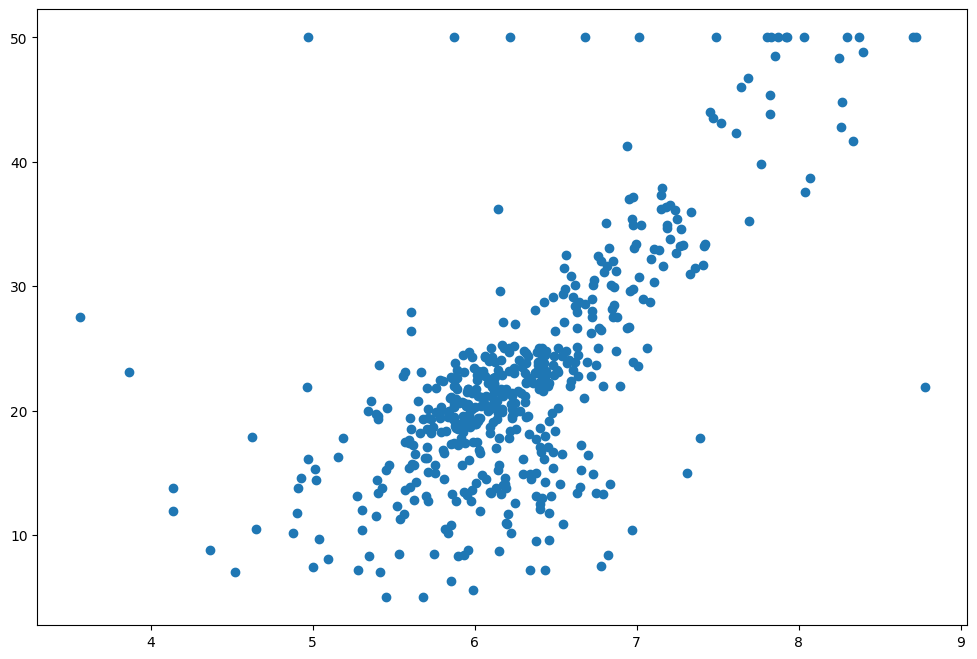

In [10]:
#TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable.
plt.figure(figsize=(12, 8))
plt.scatter(df['RM'], df['MEDV'], label='RM vs MEDV')
plt.show()

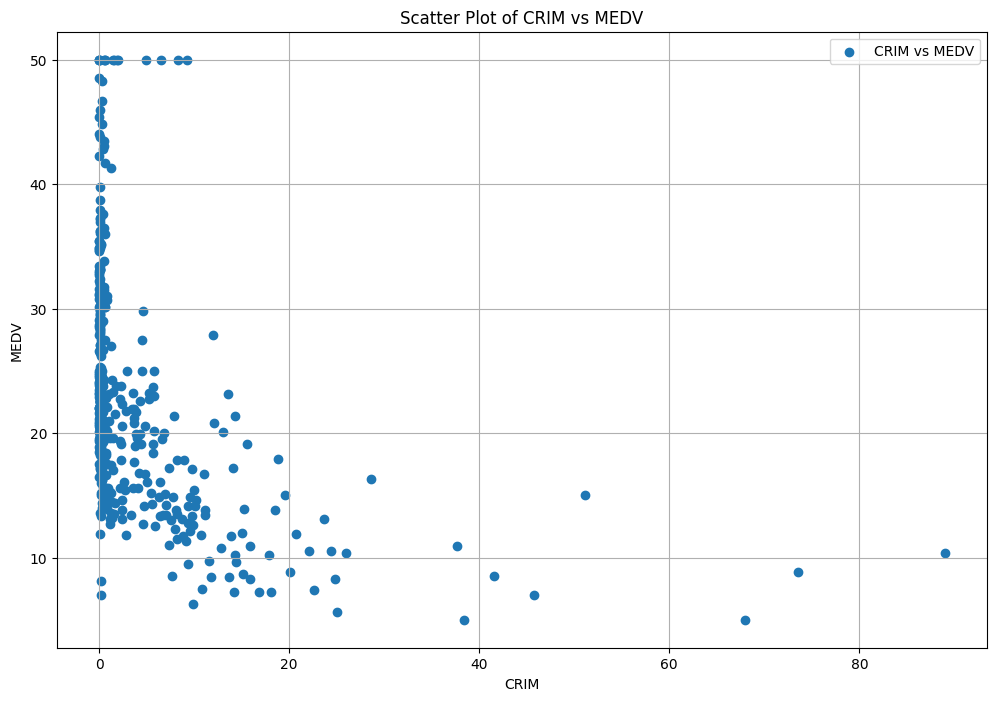

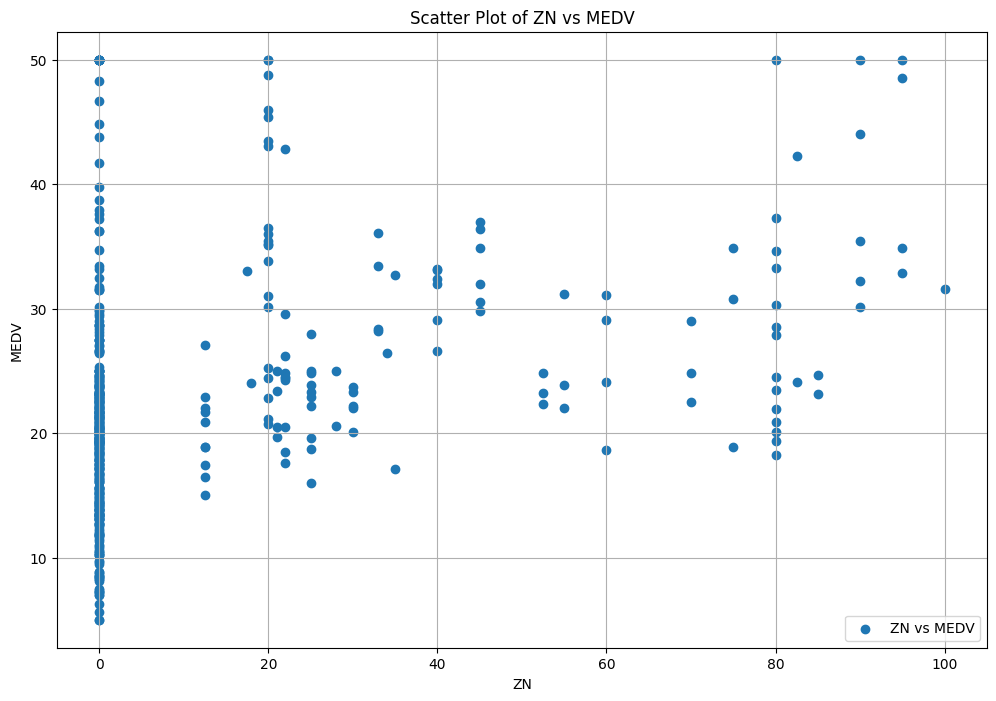

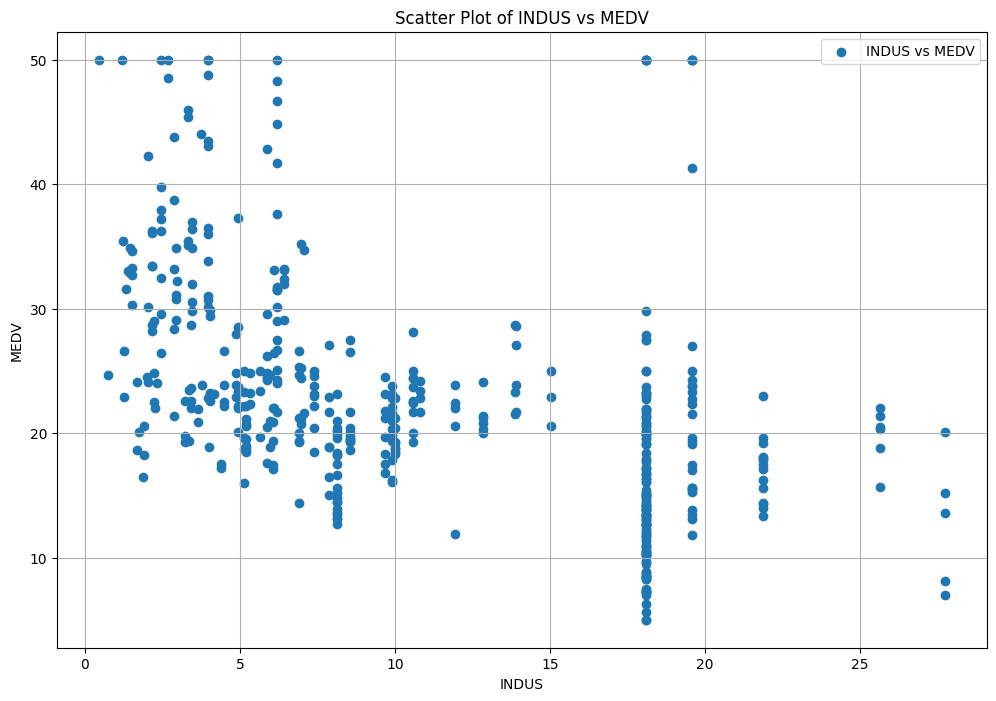

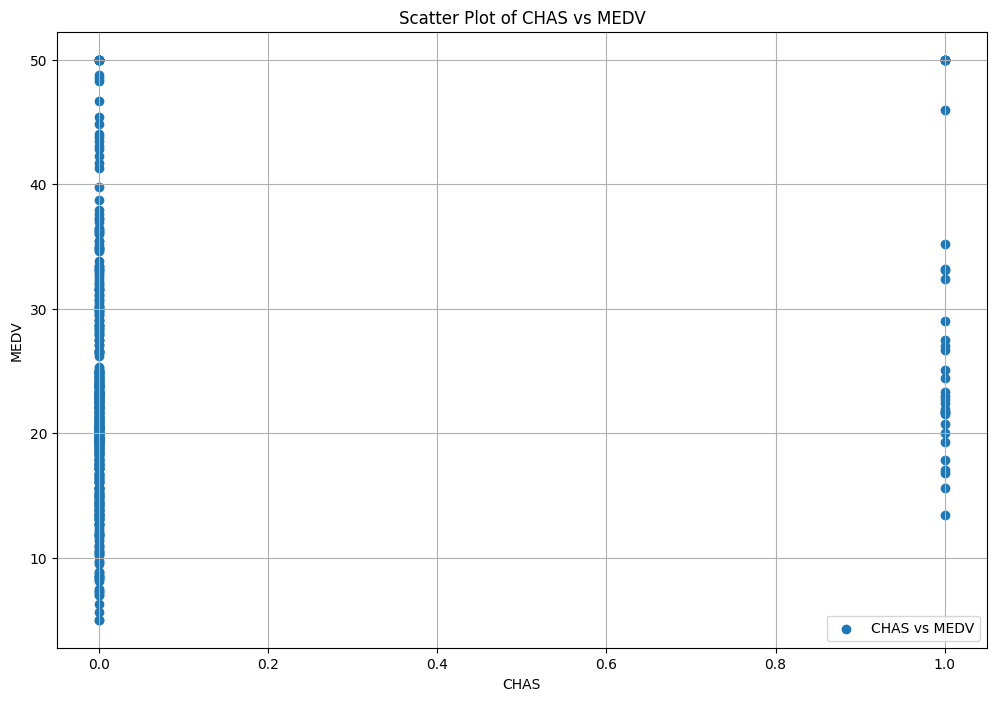

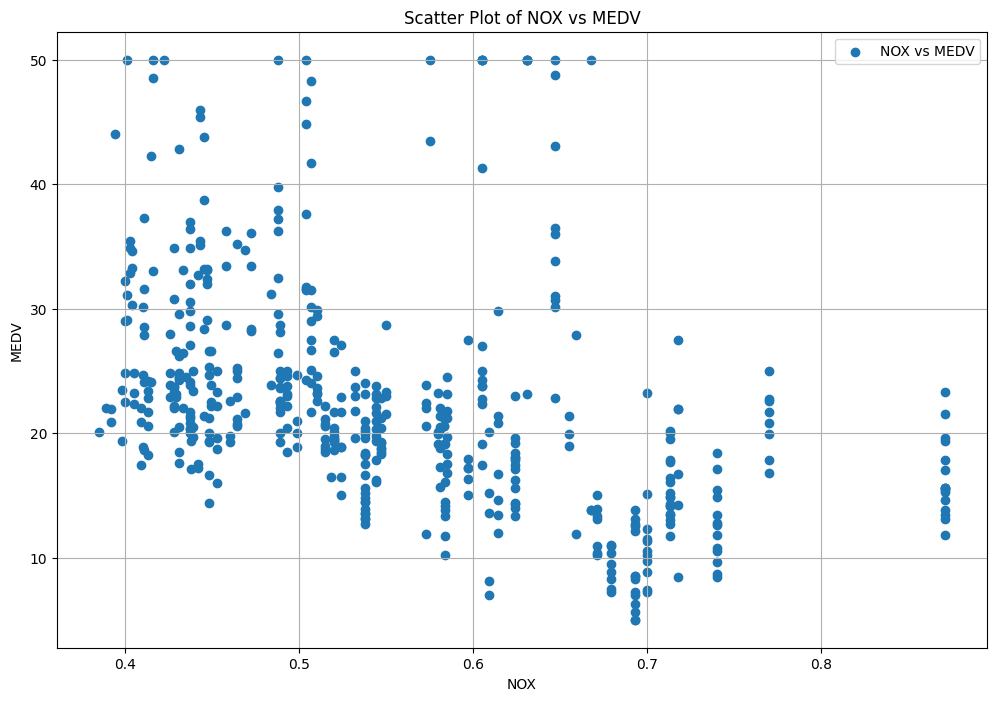

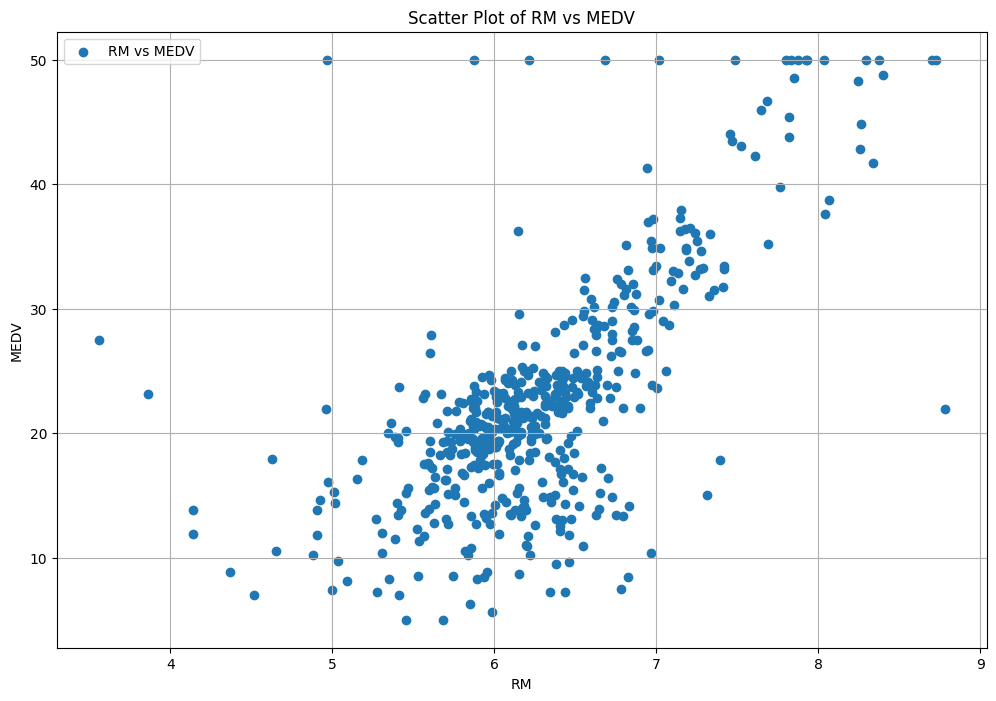

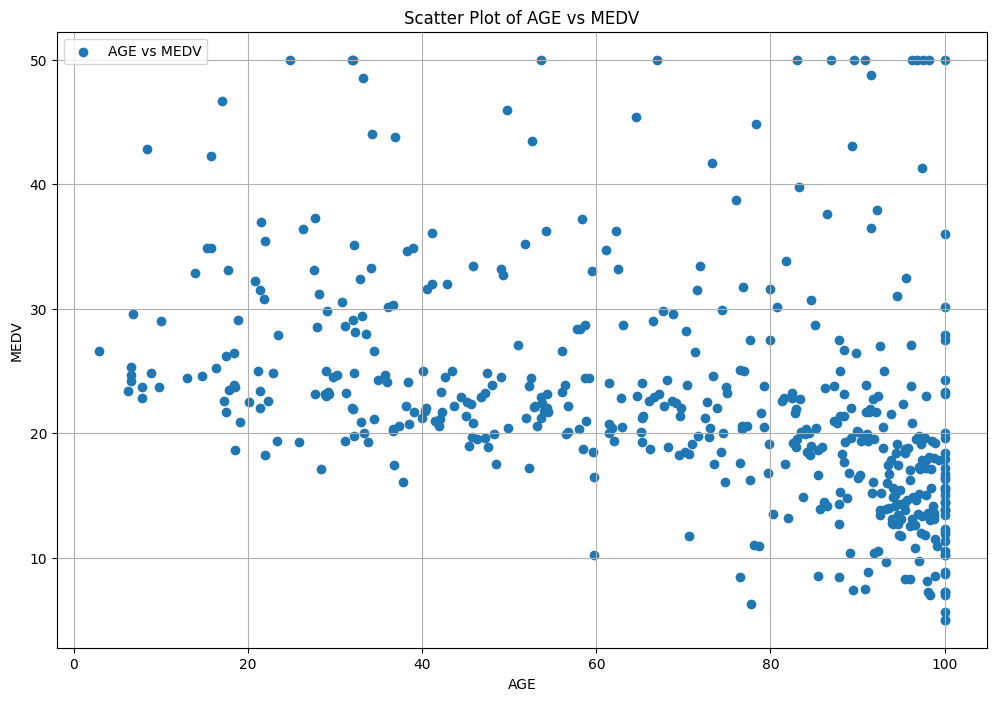

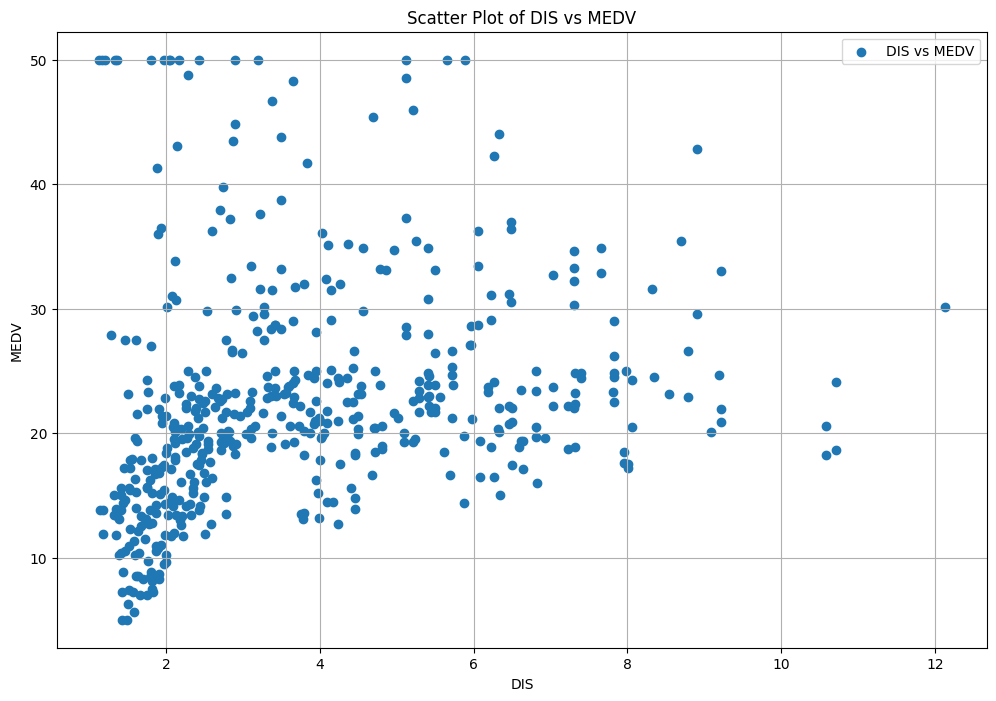

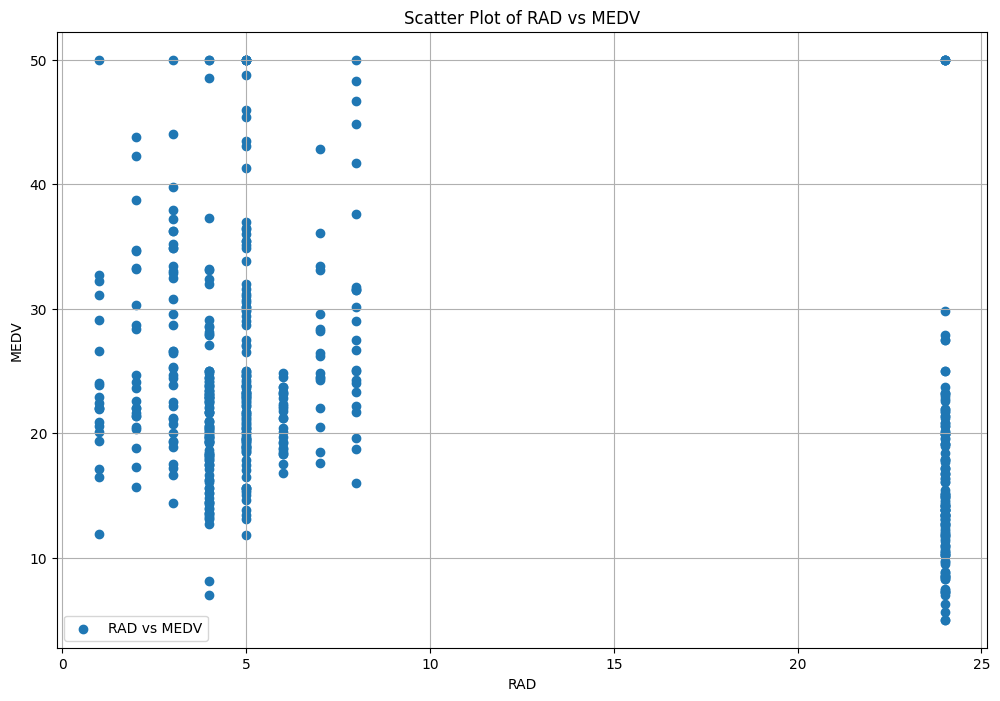

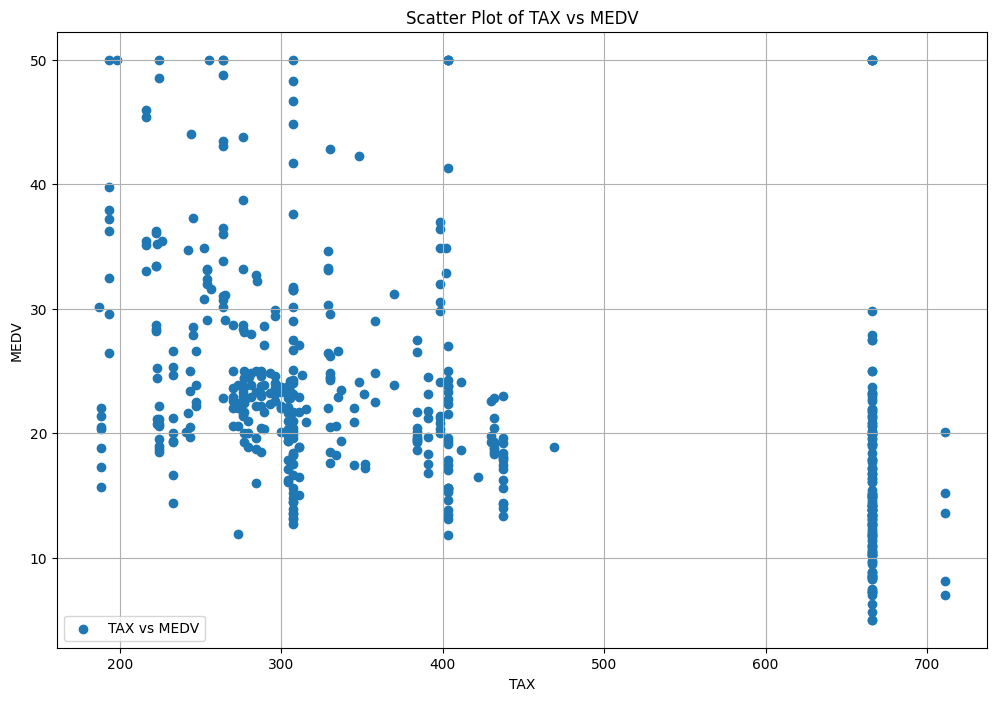

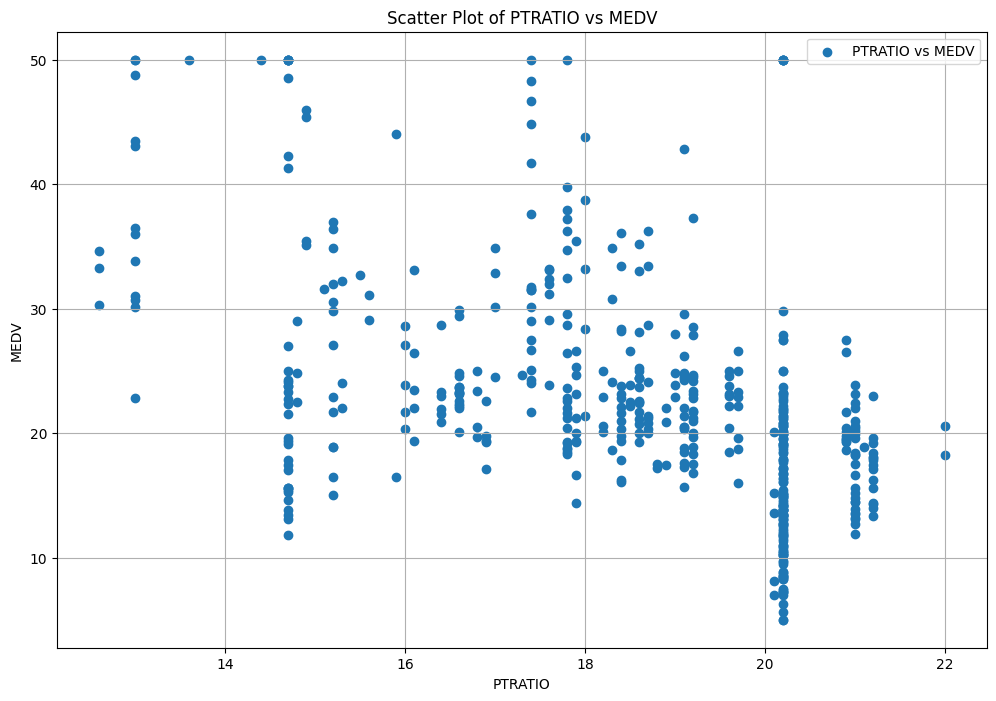

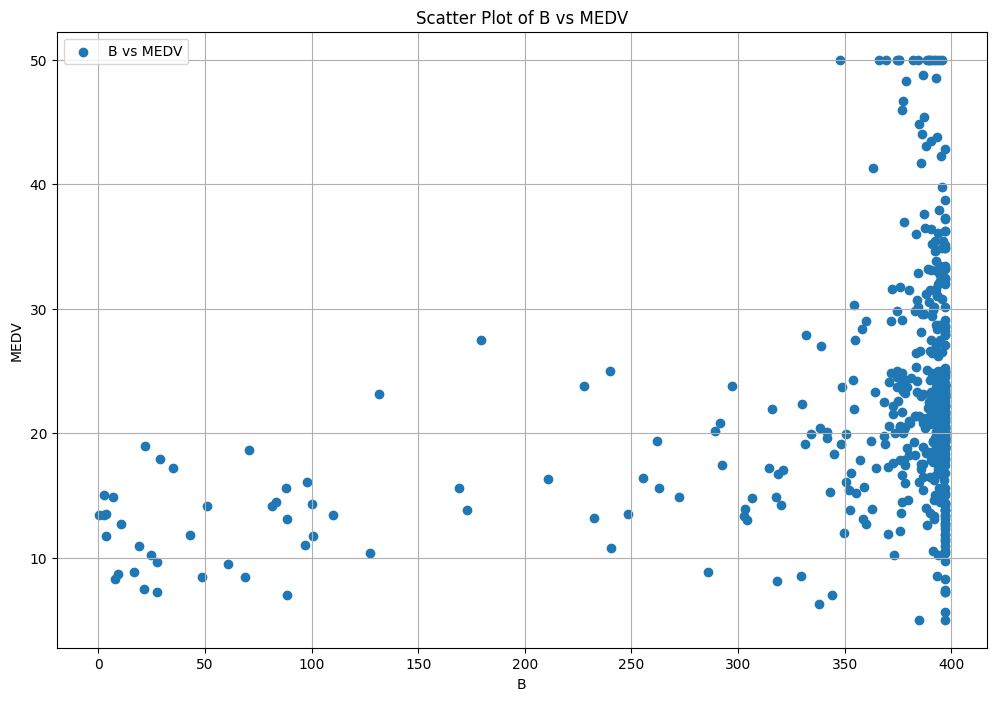

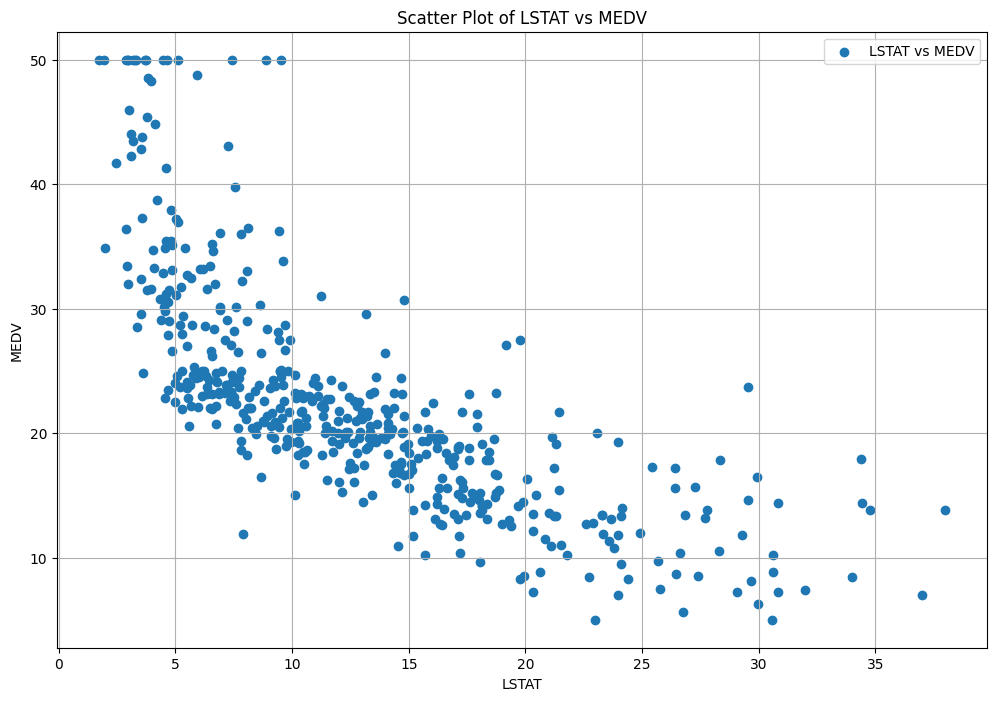

In [15]:
# TODO: Create a function to automate scatter plots for all features vs the target variable.
# Hint: The function should loop over a list of features and plot scatter plots for each.

features = df.drop('MEDV', axis=1)
target = df['MEDV']
def scatter_plot_all(df,features,target):
  for feature in features:
    plt.figure(figsize=(12, 8))
    plt.scatter(df[feature], target, label=f'{feature} vs {target.name}')
    plt.xlabel(feature)
    plt.ylabel(target.name)
    plt.title(f'Scatter Plot of {feature} vs {target.name}')
    plt.grid(True)
    plt.legend()
    plt.show()

# TODO: Use the function to visualize the relationships between multiple features and the target variable.
scatter_plot_all(df, features.columns, target)

In [16]:
# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [17]:
# TODO: Choose an appropriate regression model: Decision Tree or Random Forest.
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [18]:
# TODO: Train the model on the training data.
model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [21]:
# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean square Error",mse)
print('R-Square',r2 )

Mean square Error 7.761631568627449
R-Square 0.894160218740401


The regression model performed well. The Mean Squared Error of 7.76 indicates relatively small prediction errors, while the R-Squared value of 0.894 shows that the model explains approximately 89.4% of the variation in the target variable. Overall, these results suggest that the model provides accurate predictions and has a strong fit to the dataset.

In [23]:
# --- Model Prediction ---
# TODO: Predict house prices from a new set of feature inputs.
# Example new data: CRIM = 0.2, ZN = 12.5, INDUS = 7.07, CHAS = 0, NOX = 0.5, RM = 6.5, AGE = 68, DIS = 4.0, RAD = 2, TAX = 250, PTRATIO = 17, B = 400, LSTAT = 12
features = np.array([[0.2, 12.5, 7.07, 0, 0.5, 6.5, 68, 4.0, 2, 250, 17, 400,12]])
predicted_price = model.predict(features)
print("Predicted Price:", predicted_price[0])


Predicted Price: 22.784999999999997


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
